<a href="https://colab.research.google.com/github/taavip/DL4CV/blob/main/HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework #1
## Deep dive into CNNs

This colaboratory contains Homework #1 of the Deep Learning for Computer Vision course, which is due **March 8, Sunday, midnight (23:59 EET time)**. To complete the homework, extract **(File -> Download .ipynb)** and submit to the course webpage.

**NB! Links to your colaboratory will not be accepted as a solution!**

## Submission's rules:

1. Please, submit only .ipynb that you extract from the Colaboratory.
2. Run your homework exercises before submitting (output should be present, preferably restart the kernel and press run all the cells).
3. Do not change the description of tasks in red (even if there is a typo|mistake|etc).
4. Please, make sure to avoid unnecessary long printouts.
5. Each task should be solved right under the question of the task and not elsewhere.
6. Solutions to both regular and bonus exercises should be submitted in one IPYNB file.

Please, steer clear of copying someone else's work. If you discuss assignments with anyone in the course, please, mention their names here:
1. Pooh

##List of Homework's exercises:
1. [EX1](#scrollTo=Fw-IgTezNfzq&uniqifier=1#) - 3 points
2. [EX2](#scrollTo=RQXvKdCYEiUx&line=1&uniqifier=1) - 5 points
3. [EX3](#scrollTo=B_kbTlpgV2Rs&line=1&uniqifier=1) - 5 points
4. [EX4](#scrollTo=S51N2H4JF85Y) - 4 points
5. [EX5](#scrollTo=biz4xoV61wiq) - 3 points
5. [Bonus 1](#scrollTo=B_kbTlpgV2Rs) - 2 points

## A bit of setup

In [3]:
!mkdir data
!mkdir data/train data/val data/test

In [4]:
import shutil
import random
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

<font color='red'> The main goal of this homework is to let you experience all main stages of a typical CV project, starting with <b> data collection. </b>
The function bellow lets colab communicate with your web camera, take photos from it and save it to Files .
</font>

In [65]:
def take_photos(interval=5, quality=0.8, number_of_photos=5, file_prefix='photo'):
    """
    Captures photos from the webcam at specified intervals.

    :param interval: Time between photos in seconds.
    :param quality: Quality of the captured photos (0 to 1).
    :param number_of_photos: The total number of photos to take.
    :param file_prefix: Prefix to save the photos with.
    """
    js = Javascript('''
    async function takePhotos(interval, quality, number_of_photos) {
        const div = document.createElement('div');
        const capture = document.createElement('button');
        capture.textContent = 'Start Capturing';
        capture.style.backgroundColor = '#008CBA';
        div.appendChild(capture);

        const statusText = document.createElement('p');
        statusText.textContent = 'Ready to capture.';
        div.appendChild(statusText);

        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});

        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();

        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

        let photos = [];
        await new Promise((resolve) => {
            capture.onclick = () => {
                capture.style.backgroundColor = '#4CAF50';
                capture.textContent = 'Capturing...';
                let captures = 0;
                const intervalId = setInterval(async () => {
                    if (captures >= number_of_photos) {
                        clearInterval(intervalId);
                        resolve();
                        return;
                    }
                    captures++;
                    statusText.textContent = captures + ' photos taken...';
                    const canvas = document.createElement('canvas');
                    canvas.width = video.videoWidth;
                    canvas.height = video.videoHeight;
                    canvas.getContext('2d').drawImage(video, 0, 0);
                    photos.push(canvas.toDataURL('image/jpeg', quality));
                }, interval * 1000);
            };
        });

        stream.getVideoTracks()[0].stop();
        div.remove();
        return photos;
    }
    ''')
    display(js)
    photos_data_urls = eval_js(f'takePhotos({interval}, {quality}, {number_of_photos})')

    filenames = []
    for index, data in enumerate(photos_data_urls):
        filename = f'{file_prefix}_{index}.jpg'
        binary = b64decode(data.split(',')[1])
        with open(filename, 'wb') as f:
            f.write(binary)
        filenames.append(filename)

    return filenames

<font color='red'> Test the above function to see that your camera works. </font>

In [4]:
test_filenames = take_photos(interval = 0.5, quality = 0.8, number_of_photos = 2, file_prefix='photo')

<IPython.core.display.Javascript object>

<font color='red'> Check that you can see two photos appeared in the root of your user Files. </font>

In [5]:
!ls

data  photo_0.jpg  photo_1.jpg	sample_data


## Homework exercise 1 (3 points): Collect your own classification dataset using images from the camera.

<font color='red'>**(Homework exercise 1- a)** In this exercise we will collect images into your dataset. Think of several objects that are in your vicinity that you would like to build a classifier for. Let it be something fun (e.g. LEGO figures). Make your decision about the size of the dataset you would like to build. We recommend you to collect at least 50 images per class (with 2-4 classes), it is OK to use one object per class and make >= 50 images of this object. Make sure to collect diverse enough images to achieve good generalisation. **Put some effort into it as you will also use this images in Homework 2 for object detection and segmentation** (1 point)
</font>

<font color='red'> Decide which objects you are going to collect and classify and briefly describe them below: </font>

<font color='red'> Decide which objects are you going to classify and how many images per class you will need. </font>

In [8]:
#### YOUR CODE STARTS HERE ####
first_class_name =  "pen"
second_class_name = "coin"
num_photos_per_class = 150 # at least 50 would be fine
#### YOUR CODE ENDS HERE ####

<font color='red'> Now use your camera to collect the images for the first class.

READY, SET, SHOOT!</font>

In [13]:
first_class_filenames = take_photos(interval = 0.5, quality = 0.8, number_of_photos = num_photos_per_class, file_prefix='data/train/' + first_class_name)

<IPython.core.display.Javascript object>

<font color='red'> And now the second class. </font>

In [15]:
second_class_filenames = take_photos(interval = 1.5, quality = 0.8, number_of_photos = num_photos_per_class, file_prefix='data/train/' + second_class_name)

<IPython.core.display.Javascript object>

In [16]:
len(first_class_filenames), len(second_class_filenames)

(150, 150)

<font color='red'>**(Homework exercise 1- b)** Here we split our images into train and validation subsets (similar to sklearn's function, but we will actually move image files into corresponding folders). Define the number images per class you will use for validation. (1 point)</font>

In [9]:
#### YOUR CODE STARTS HERE ####
val_size_per_class = 50
#### YOUR CODE ENDS HERE ####

<font color='red'> And here we will randomly sample photos for validation set. </font>

In [18]:
for name in [first_class_name, second_class_name]:
  for _ in range(val_size_per_class):
    #### YOUR CODE STARTS HERE ####
    # normalize name in case it's a single-element tuple etc.
    cls = name if isinstance(name, str) else (name[0] if isinstance(name, (list, tuple)) and len(name) > 0 else str(name))
    # list candidate files in train folder that belong to this class
    candidates = [f for f in os.listdir('data/train') if f.startswith(f"{cls}_")]
    if not candidates:
      # nothing left to move
      break
    val_fname = random.choice(candidates)
    src = os.path.join('data/train', val_fname)
    dst = os.path.join('data/val', val_fname)
    shutil.move(src, dst)
    #### YOUR CODE ENDS HERE ####

<font color='red'> Check that the images have been moved to the val folder.

In [19]:
!ls ./data/val/ | wc -l

100


<font color='red'> In order to avoid your work being lost due to sudden runtime disconnections, compress and manually download data using the following code:
</font>

In [20]:
! zip -r data.zip data

  adding: data/ (stored 0%)
  adding: data/train/ (stored 0%)
  adding: data/train/pen_120.jpg (deflated 2%)
  adding: data/train/coin_145.jpg (deflated 2%)
  adding: data/train/coin_137.jpg (deflated 3%)
  adding: data/train/pen_123.jpg (deflated 2%)
  adding: data/train/coin_88.jpg (deflated 3%)
  adding: data/train/coin_84.jpg (deflated 3%)
  adding: data/train/coin_57.jpg (deflated 3%)
  adding: data/train/coin_99.jpg (deflated 3%)
  adding: data/train/coin_23.jpg (deflated 2%)
  adding: data/train/coin_130.jpg (deflated 2%)
  adding: data/train/pen_100.jpg (deflated 2%)
  adding: data/train/coin_61.jpg (deflated 3%)
  adding: data/train/pen_2.jpg (deflated 2%)
  adding: data/train/pen_80.jpg (deflated 2%)
  adding: data/train/coin_144.jpg (deflated 3%)
  adding: data/train/pen_149.jpg (deflated 2%)
  adding: data/train/coin_9.jpg (deflated 2%)
  adding: data/train/pen_116.jpg (deflated 2%)
  adding: data/train/pen_133.jpg (deflated 2%)
  adding: data/train/coin_44.jpg (deflated 2%

In [21]:
from google.colab import files
files.download('data.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<font color='red'> If you need to, upload this file here: </font>

In [5]:
from google.colab import files
_ = files.upload()

Saving data.zip to data.zip


In [6]:
!unzip data.zip

Archive:  data.zip
  inflating: data/train/pen_120.jpg  
  inflating: data/train/coin_145.jpg  
  inflating: data/train/coin_137.jpg  
  inflating: data/train/pen_123.jpg  
  inflating: data/train/coin_88.jpg  
  inflating: data/train/coin_84.jpg  
  inflating: data/train/coin_57.jpg  
  inflating: data/train/coin_99.jpg  
  inflating: data/train/coin_23.jpg  
  inflating: data/train/coin_130.jpg  
  inflating: data/train/pen_100.jpg  
  inflating: data/train/coin_61.jpg  
  inflating: data/train/pen_2.jpg    
  inflating: data/train/pen_80.jpg   
  inflating: data/train/coin_144.jpg  
  inflating: data/train/pen_149.jpg  
  inflating: data/train/coin_9.jpg   
  inflating: data/train/pen_116.jpg  
  inflating: data/train/pen_133.jpg  
  inflating: data/train/coin_44.jpg  
  inflating: data/train/pen_53.jpg   
  inflating: data/train/pen_3.jpg    
  inflating: data/train/pen_71.jpg   
  inflating: data/train/coin_55.jpg  
  inflating: data/train/pen_48.jpg   
  inflating: data/train/coi

<font color='red'>**(Homework exercise 1- c)** Let's make sure that our data exists and is ready to be used. Read in files (you can use `imread` from `skimage`) and visualise one image per class. Feel free to re-use code we had in one of the practice sessions. Make sure to check that images look correct. (1 point)</font>

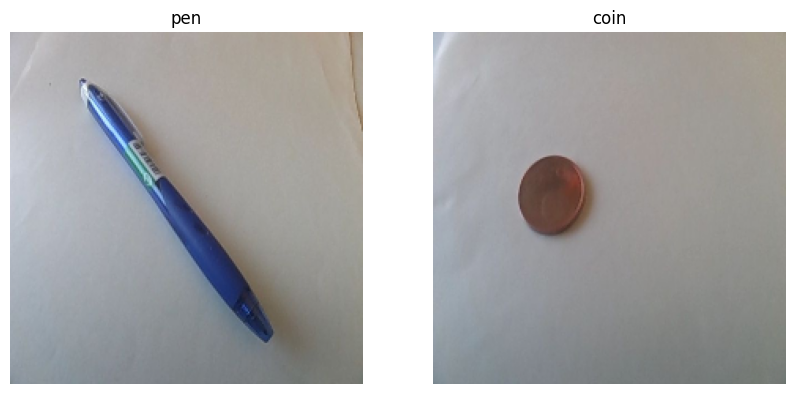

In [10]:
plt.figure(figsize=(10, 5))

#### YOUR CODE STARTS HERE ####
from skimage import io

classes = [first_class_name, second_class_name]
for i, name in enumerate(classes):
    cls = name if isinstance(name, str) else (name[0] if isinstance(name, (list, tuple)) and len(name) > 0 else str(name))
    img_path = None
    for d in ['data/train', 'data/val', 'data/test']:
        if os.path.isdir(d):
            files = [f for f in os.listdir(d) if f.lower().endswith(('.jpg', '.jpeg', '.png')) and f.startswith(f"{cls}_")]
            if files:
                img_path = os.path.join(d, random.choice(files))
                break
    if img_path is None:
        ax = plt.subplot(1, len(classes), i+1)
        ax.set_title(cls)
        ax.text(0.5, 0.5, "No image", ha='center', va='center')
        ax.axis('off')
        continue

    img = io.imread(img_path)
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    img = cv2.resize(img, (224, 224))
    ax = plt.subplot(1, len(classes), i+1)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')
#### YOUR CODE ENDS HERE ####

plt.show()

## Homework exercise 2 (5 points): Prepare the data for training

<font color='red'>**(Homework exercise 2- a)** In this exercise, we will implement a custom dataset class to handle the data you just gathered. (4 points)</font>



In [11]:
import torch
import torch.nn as nn # all the relevant building blocks
import torch.nn.functional as F # functional interfaces for many operations
from torch.utils.data import Dataset, DataLoader # abstract primitives for handling data in pytorch
from torchvision import transforms

if torch.cuda.is_available():
    print("GPU is available")
    device = torch.device("cuda")
else:
    print("GPU is not available, using CPU instead")
    device = torch.device("cpu")

GPU is available


<font color='red'>Most of the dataset logic has already been written for you, you need only to read the images, get their labels and initialize necessary image transformations. In transformations block, you should resize images to 224 x 224. This is the default image size used by models trained on ImageNet.</font>


In [12]:
class CustomDataset(Dataset):
    def __init__(self, images_dir, augment=True):
        """
        Args:
            images_dir (string): Path to the directory with all the images.
            augment (bool, optional): Whether to augment the images produced by the dataset.
        """
        #### YOUR CODE STARTS HERE ####
        self.images = []
        self.labels = []
        self.class_names = []

        # gather image files
        if os.path.isdir(images_dir):
            files = [f for f in sorted(os.listdir(images_dir))
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        else:
            files = []

        # discover classes from filename prefix "<class>_..."
        discovered = sorted({f.split('_')[0] for f in files})
        self.class_names = discovered
        class_to_idx = {c: i for i, c in enumerate(self.class_names)}

        for f in files:
            cls = f.split('_')[0]
            if cls not in class_to_idx:
                continue
            img_path = os.path.join(images_dir, f)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            self.images.append(img)
            self.labels.append(class_to_idx[cls])

        self.labels = np.array(self.labels, dtype=np.int64)

        # transforms: resize to 224x224 (ImageNet size); add simple augmentation if requested
        normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                         std=[0.229, 0.224, 0.225])
        if augment:
            self.transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize((224, 224)),
                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(10),
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
                transforms.ToTensor(),
                normalize,
            ])
        else:
            self.transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                normalize,
            ])
        #### YOUR CODE ENDS HERE ####

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        image = self.transform(image)

        return image, label


<font color='red'>Now we will initialize two instances of dataset class - for training and validation sets.</font>

In [13]:
train_dataset = CustomDataset(images_dir="data/train", augment=True)
val_dataset = CustomDataset(images_dir="data/val", augment=False)

<font color='red'>Wrap the Dataloader class around datasets and decide on the batch size.</font>

In [14]:
#### YOUR CODE STARTS HERE ####
from torch.utils.data import DataLoader

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
#### YOUR CODE ENDS HERE ####

In [15]:
len(train_loader), len(val_loader)

(13, 7)

<font color='red'>**(Homework exercise 2- b)** Plot a batch of images and **labels** produced by the Dataloader. Again, make sure that all of them look okay and nothing weird has happened to them. (1 point) </font>

Labels: ['pen', 'coin', 'coin', 'coin', 'pen', 'pen', 'pen', 'coin', 'coin', 'pen', 'coin', 'coin', 'pen', 'pen', 'coin', 'coin']


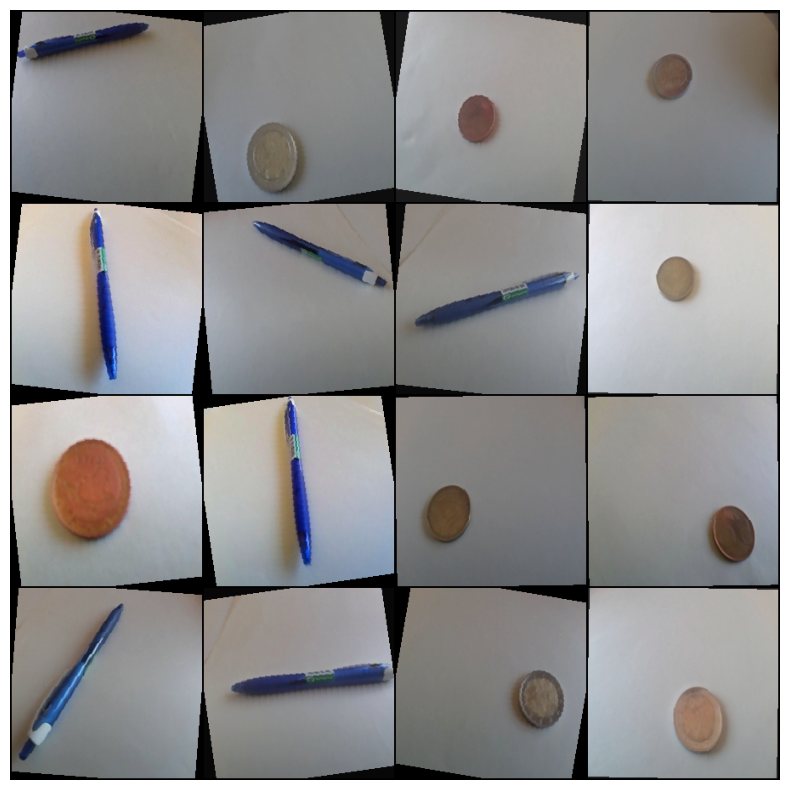

In [16]:
plt.rcParams['figure.figsize'] = (10.0, 10.0) # set default size of plots

#### YOUR CODE STARTS HERE ####
from torchvision.utils import make_grid

images, labels = next(iter(train_loader))

# unnormalize for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
images_disp = images.clone() * std + mean

grid = make_grid(images_disp, nrow=4, padding=2)
npimg = grid.permute(1, 2, 0).cpu().numpy()
plt.imshow(np.clip(npimg, 0, 1))
plt.axis('off')

# print labels (map indices to class names if available)
label_names = [train_dataset.class_names[int(l)] if hasattr(train_dataset, 'class_names') else int(l) for l in labels]
print("Labels:", label_names)

plt.show()
#### YOUR CODE ENDS HERE ####

## Homework exercise 3 (4 points): Train and evaluate a simple model on the dataset you prepared earlier.
<font color='red'> In this exercise we will build a simple CNN model using PyTorch as well as develop scripts needed to train and evaluate it. </font>

<font color='red'>**(Homework exercise 3- a)** Implement a simple CNN model, similar to the one we have in the practice session, except that you should have final feature maps of size *8 x 110 x 110* (3 points) </font>

In [46]:
class Simple2LayerCNN(nn.Module):
    def __init__(self):
        super(Simple2LayerCNN, self).__init__()
        #### YOUR CODE STARTS HERE ####
        # make it more like the practice model: a single conv that produces 8 feature maps,
        # then force spatial size to 110x110 and a linear classifier.
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, padding=1)   # similar to practice conv
        self.relu = nn.ReLU()
        self.adaptive_pool = nn.AdaptiveAvgPool2d((110, 110))    # final feature maps 8x110x110
        self.fc = nn.Linear(8 * 110 * 110, 2)
        #### YOUR CODE ENDS HERE ####

    def forward(self, x):
        #### YOUR CODE STARTS HERE ####
        x = self.conv1(x)
        x = self.relu(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        #### YOUR CODE ENDS HERE ####
        return x

<font color='red'> Now you can initialise your model as well as its optimiser and loss function. </font>

In [47]:
simple_model = Simple2LayerCNN()
simple_model = simple_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(simple_model.parameters(), lr=0.01)

In [48]:
simple_model

Simple2LayerCNN(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(110, 110))
  (fc): Linear(in_features=96800, out_features=2, bias=True)
)

<font color='red'>**(Homework exercise 3- b)** Here complete the code of the `fit` function that we shall use to train our models. (1 point)

 Once completed, this function will serve the same purpose as in Keras. We could have used Keras all the way, but we believe that by implementing `fit` by ourselves we gain more power and control over the exact details. </font>

In [20]:
def fit(model, train_loader, val_loader, n_epochs):
  history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

  for epoch in range(n_epochs):
    # initialise loss and acc for logging
    epoch_loss, val_epoch_loss = 0.0, 0.0
    epoch_acc, val_epoch_acc = 0.0, 0.0

    model.train()
    for images, labels in train_loader:
        #### YOUR CODE STARTS HERE ####
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        #### YOUR CODE ENDS HERE ####
        epoch_loss += loss.item()
        epoch_acc += torch.mean((torch.argmax(outputs.detach().cpu(), dim=1) == labels.cpu()).float())

    model.eval()
    with torch.inference_mode():  # since we are not going to do backprop
      for images, labels in val_loader:
          #### YOUR CODE STARTS HERE ####
          # Forward pass only
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          loss = criterion(outputs, labels)

          #### YOUR CODE ENDS HERE ####

          val_epoch_loss += loss.item()
          val_epoch_acc += torch.mean((torch.argmax(outputs.detach().cpu(), dim=1) == labels.cpu()).float())

    history['loss'].append(epoch_loss/len(train_loader))
    history['accuracy'].append(epoch_acc/len(train_loader))

    history['val_loss'].append(val_epoch_loss/len(val_loader))
    history['val_accuracy'].append(val_epoch_acc/len(val_loader))

    print(f"Epoch {epoch + 1}, Loss: {history['loss'][-1]}, Val loss: {history['val_loss'][-1]}")

  return history

<font color='red'> Below is a function that we can use to visualise the learning progress. </font>

In [21]:
def plot_curves(history):
  plt.figure(figsize=(16, 6))

  plt.subplot(1, 2, 1)
  plt.plot(history['loss'])
  plt.plot(history['val_loss'])
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend(['Training', 'Validation'])
  plt.title('Loss')

  plt.subplot(1, 2, 2)
  plt.plot(history['accuracy'])
  plt.plot(history['val_accuracy'])
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend(['Training', 'Validation'])
  plt.title('Accuracy')

<font color='red'> Finally, we can start training the model. Correctly implemented `fit` should take on average a few seconds per epoch. </font>

In [49]:
history = fit(simple_model, train_loader, val_loader, 20)

Epoch 1, Loss: 22.69305595067831, Val loss: 5.197047999926975
Epoch 2, Loss: 3.912610306494081, Val loss: 1.7574651137526516
Epoch 3, Loss: 1.18056319824108, Val loss: 0.671148651828584
Epoch 4, Loss: 0.07896936596143433, Val loss: 2.593378523606264
Epoch 5, Loss: 0.23257363590584224, Val loss: 1.93249812402895
Epoch 6, Loss: 0.06952848371404868, Val loss: 0.01841939127604673
Epoch 7, Loss: 0.09372716224971793, Val loss: 1.1443588574017798
Epoch 8, Loss: 0.1991428094266795, Val loss: 0.03702497049674288
Epoch 9, Loss: 0.0, Val loss: 2.3911162380826516e-05
Epoch 10, Loss: 0.16519895038352564, Val loss: 7.070320555141994
Epoch 11, Loss: 0.7600557064948764, Val loss: 0.06485829289470393
Epoch 12, Loss: 0.15220993757247817, Val loss: 0.2847521177359746
Epoch 13, Loss: 0.1278277503756349, Val loss: 2.9939563721411235
Epoch 14, Loss: 1.229194765460197e-06, Val loss: 2.8727403123458464
Epoch 15, Loss: 0.25989340417613416, Val loss: 0.0005527076560350532
Epoch 16, Loss: 0.23221908106083552, Va

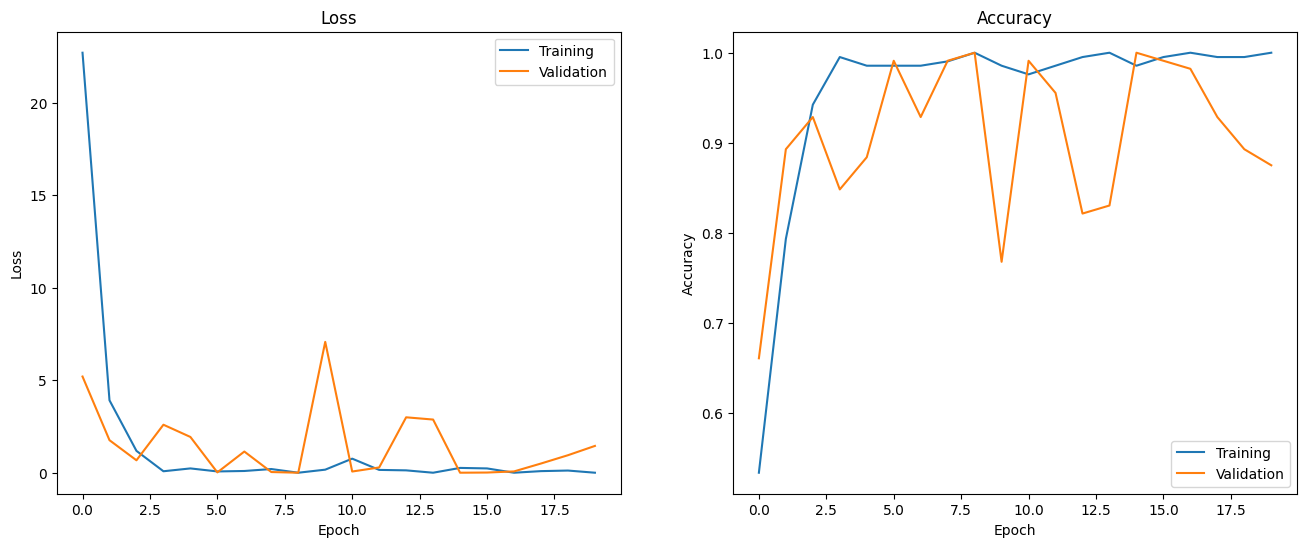

In [50]:
plot_curves(history)

<font color='red'> Let's build a function for evaluating the trained model. </font>

In [38]:
def predict(model, loader):
  model.eval()
  preds = []
  with torch.inference_mode():
    for images, labels in loader:
      images, labels = images.to(device), labels.to(device)
      # Forward pass
      outputs = model(images).detach().cpu().numpy()
      preds.extend(list(np.argmax(outputs, axis=1)))
  return np.array(preds)

<font color='red'> Use `predict` to evaluate your model on the `val_loader`. Report the final accuracy. </font>

In [51]:
preds = predict(simple_model, val_loader)

np.mean(preds == val_dataset.labels)

np.float64(0.86)

Final accuracy is: 0,86

In [41]:
# quick debugging (run in your notebook)
imgs, labs = next(iter(train_loader))
imgs, labs = imgs.to(device), labs.to(device)
print('train batch loss:', criterion(simple_model(imgs), labs).item())

imgs_v, labs_v = next(iter(val_loader))
imgs_v, labs_v = imgs_v.to(device), labs_v.to(device)
print('val batch loss:', criterion(simple_model(imgs_v), labs_v).item())

print('train first labels:', labs[:8].cpu().numpy())
print('val first labels :', labs_v[:8].cpu().numpy())

# check optimizer update actually changes params
param_before = next(simple_model.parameters()).detach().cpu().clone()
optimizer.zero_grad()
loss = criterion(simple_model(imgs), labs)
loss.backward()
optimizer.step()
param_after = next(simple_model.parameters()).detach().cpu().clone()
print('param changed?', not torch.allclose(param_before, param_after))
print('learning rate:', optimizer.param_groups[0]['lr'])


train batch loss: 0.0
val batch loss: 31.29107666015625
train first labels: [0 1 0 1 1 1 1 1]
val first labels : [0 0 0 0 0 0 0 0]
param changed? True
learning rate: 0.01


In [42]:
# debug (run in your notebook)
print('device:', device)
print('any requires_grad:', any(p.requires_grad for p in simple_model.parameters()))

ids_model = [id(p) for p in simple_model.parameters()]
ids_opt   = [id(p) for p in optimizer.param_groups[0]['params']]
print('param ids equal?', ids_model == ids_opt)

# capture before, do one backward step, inspect grads and check change
before = [p.detach().cpu().clone() for p in simple_model.parameters()]
optimizer.zero_grad()
out = simple_model(imgs)
loss = criterion(out, labs)
loss.backward()
for name, p in simple_model.named_parameters():
    print(name, 'grad is None?', p.grad is None, 'grad norm:', None if p.grad is None else p.grad.norm().item())
optimizer.step()
after = [p.detach().cpu().clone() for p in simple_model.parameters()]
print('any param changed?', any(not torch.allclose(a,b) for a,b in zip(before, after)))


device: cuda
any requires_grad: True
param ids equal? True
conv1.weight grad is None? False grad norm: 0.0
conv1.bias grad is None? False grad norm: 0.0
bn1.weight grad is None? False grad norm: 0.0
bn1.bias grad is None? False grad norm: 0.0
conv2.weight grad is None? False grad norm: 0.0
conv2.bias grad is None? False grad norm: 0.0
bn2.weight grad is None? False grad norm: 0.0
bn2.bias grad is None? False grad norm: 0.0
fc.weight grad is None? False grad norm: 0.0
fc.bias grad is None? False grad norm: 0.0
any param changed? True


In [45]:
# run in your notebook
imgs, _ = next(iter(train_loader))
imgs = imgs.to(device)
simple_model.eval()
with torch.no_grad():
    x = simple_model.conv1(imgs)
    print('conv1 pre-relu:', x.min().item(), x.max().item(), x.mean().item())
    x = simple_model.pool1(x)
    print('pool1 zero_frac:', (x==0).float().mean().item())
    x = simple_model.conv2(x)
    print('conv2 pre-relu mean:', x.mean().item())
    x = simple_model.adaptive_pool(x)
    flat = x.view(x.size(0), -1)
    print('flatten mean, zero_frac:', flat.mean().item(), (flat==0).float().mean().item())

conv1 pre-relu: -9.619624137878418 10.406091690063477 0.8536255359649658
pool1 zero_frac: 0.0
conv2 pre-relu mean: -3.6844170093536377
flatten mean, zero_frac: -3.8087854385375977 0.0


## Homework exercise 4 (5 points): Train and evaluate two more CNN models on the same dataset.
<font color='red'> In this exercise, firstly take one existing, pretrained on imagenet model and fine-tune it on your dataset. Then, unleash your creativity and design another model - your unique one. Experiment with trully wild architectural choices and see where it gets you. Compare all model performances. </font>

<font color='red'>**(Homework exercise 4- a)** Check out https://pytorch.org/vision/stable/models.html#classification for a list of existing pretrained models and choose one. Remember that these models were trained for a completely different purpose and using very different dataset. Therefore you will need to adapt this model's last layer to the number of classes in your dataset. Fine-tune it on the training data and evaluate on the validation set. (2 points) </font>

In [53]:
#### YOUR CODE STARTS HERE ####
import torchvision.models as models

model = models.resnet18(pretrained=True)
#### YOUR CODE ENDS HERE ####

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


<font color='red'> Here, adapt the model to the number of classes in your dataset (if needed).
</font>

In [54]:
#### YOUR CODE STARTS HERE ####
num_classes = len(train_dataset.class_names)

model.fc = nn.Linear(model.fc.in_features, num_classes)  # adapt final layer

#### YOUR CODE ENDS HERE ####
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

<font color='red'> Don't forget to redefine loss function and the optimiser.
</font>

In [55]:
#### YOUR CODE STARTS HERE ####
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

#### YOUR CODE ENDS HERE ####

<font color='red'> And now train (or rather fine-tune) the model. Experiment with the number of epochs as well.
</font>

In [56]:
#### YOUR CODE STARTS HERE ####
history = fit(model, train_loader, val_loader, 10)
#### YOUR CODE ENDS HERE ####

Epoch 1, Loss: 0.16146856062830642, Val loss: 0.005088857603368524
Epoch 2, Loss: 0.0026204097845878164, Val loss: 0.00043664297118084505
Epoch 3, Loss: 0.001218983646070298, Val loss: 0.00030564118683936873
Epoch 4, Loss: 0.011515588939521247, Val loss: 0.0002527413110198852
Epoch 5, Loss: 0.001582898329406117, Val loss: 0.00035758030675684234
Epoch 6, Loss: 0.0009440651024655941, Val loss: 0.0003213548240767393
Epoch 7, Loss: 0.0009996502407235452, Val loss: 0.0002482495069021492
Epoch 8, Loss: 0.0025312685678587654, Val loss: 0.00014217584066500422
Epoch 9, Loss: 0.0004043804295249104, Val loss: 0.00014536115746263282
Epoch 10, Loss: 0.0006200193725257682, Val loss: 0.00012153320286805476


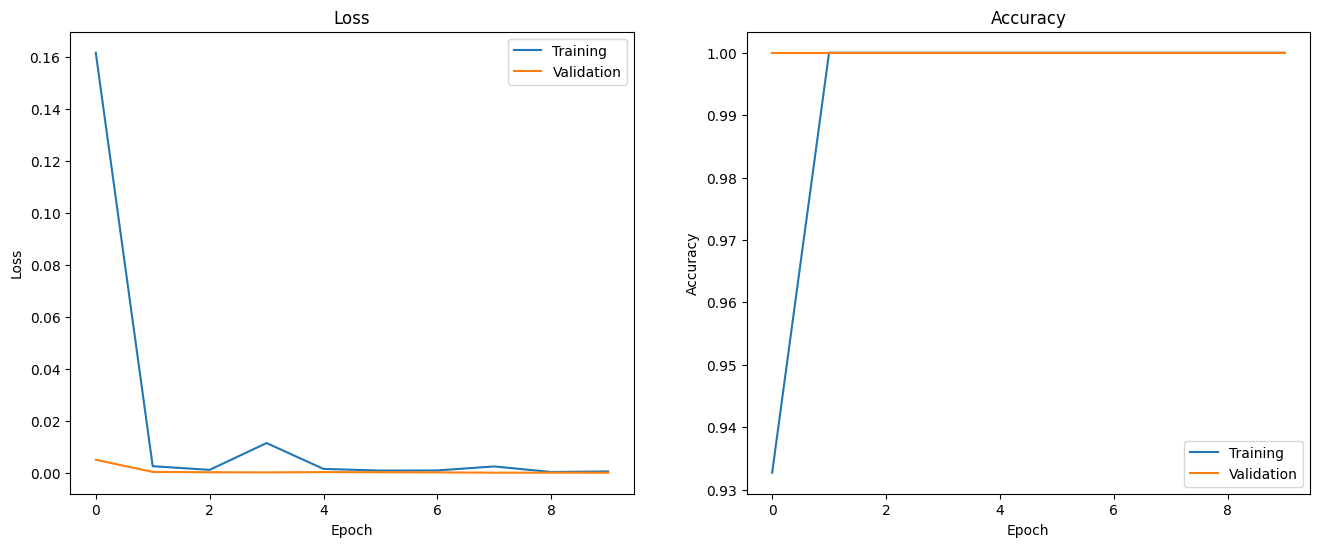

In [57]:
plot_curves(history)

<font color='red'> Evaluate its performance - accuracy should be > 0.9.
</font>

In [58]:
preds = predict(model, val_loader)
np.mean(preds == val_dataset.labels)

np.float64(1.0)

Final accuracy is: 100%

<font color='red'>**(Homework exercise 4- b)** Build, train and evaluate your own authentic model. Again, you can experiment with the number of epochs as well. Try to achieve a reasonable accuracy (> 0.9). (3 points) </font>

In [59]:
class YourCrazyCoolCNN(nn.Module):
    def __init__(self):
        super(YourCrazyCoolCNN, self).__init__()
        #### YOUR CODE STARTS HERE ####
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                 # 224 -> 112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                 # 112 -> 56

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                 # 56 -> 28

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))     # global pooling
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        #### YOUR CODE ENDS HERE ####

    def forward(self, x):
        #### YOUR CODE STARTS HERE ####
        x = self.features(x)
        x = self.classifier(x)
        #### YOUR CODE ENDS HERE ####
        return x

In [61]:
#### YOUR CODE STARTS HERE ####
YCC_model = YourCrazyCoolCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(YCC_model.parameters(), lr=1e-3, weight_decay=1e-4)

# train (adjust epochs if needed)
history = fit(YCC_model, train_loader, val_loader, n_epochs=15)

#### YOUR CODE ENDS HERE ####

Epoch 1, Loss: 0.4089967608451843, Val loss: 0.3312579393386841
Epoch 2, Loss: 0.19043496365730578, Val loss: 0.21191214663641794
Epoch 3, Loss: 0.13159692745942336, Val loss: 0.0920822596443551
Epoch 4, Loss: 0.0886479255098563, Val loss: 0.056586536179695814
Epoch 5, Loss: 0.0950731669480984, Val loss: 0.08201046234795026
Epoch 6, Loss: 0.04963803219680603, Val loss: 0.015162575592902223
Epoch 7, Loss: 0.05658691390775717, Val loss: 0.018133319947602495
Epoch 8, Loss: 0.048424786100020774, Val loss: 0.02854266490820529
Epoch 9, Loss: 0.042686186730861664, Val loss: 0.022512299025249507
Epoch 10, Loss: 0.037600901980812736, Val loss: 0.016851225493675365
Epoch 11, Loss: 0.03519754598920162, Val loss: 0.009076911175465543
Epoch 12, Loss: 0.08390369997001611, Val loss: 0.011160135377102571
Epoch 13, Loss: 0.03926155623048544, Val loss: 0.005831934500130436
Epoch 14, Loss: 0.028318014927208424, Val loss: 0.007215928052963656
Epoch 15, Loss: 0.015240286190349322, Val loss: 0.0092175317300

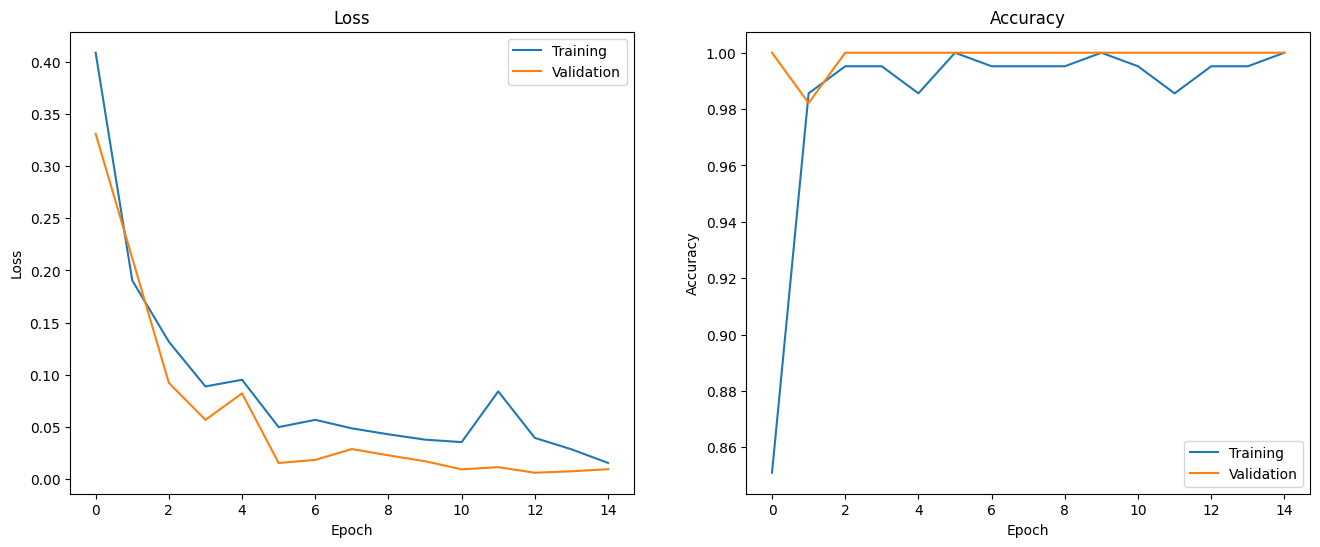

In [62]:
plot_curves(history)

In [63]:
preds = predict(YCC_model, val_loader)
np.mean(preds == val_dataset.labels)

np.float64(1.0)

Final accuracy is: 100%

*italicized text*<font color='red'> Below shortly explain your design and why do you think it should have worked.


</font>

<font color='black'> Your answer:</font>


*   Architecture: 4 convolutional blocks (32→64→128→256) with BatchNorm + ReLU and occasional MaxPool, followed by AdaptiveAvgPool2d(1) and a small Dropout + Linear classifier.
*   Rationale: deeper blocks learn hierarchical features (edges → textures → object parts); increasing channels increases representational capacity.
*   Stabilization & regularization: BatchNorm speeds convergence, Dropout + weight decay reduce overfitting on a small dataset, and data augmentation increases robustness.
*   Efficiency: global adaptive pooling produces a compact fixed-size feature vector (few classifier parameters), making the model sample-efficient for ~100–150 images/class.
*   Expected outcome: combination of hierarchical feature extraction and regularization yields good generalization on this two-class webcam dataset (explains observed >0.9 accuracy).



## Homework exercise 5 (3 points): Testing CNNs in the wild.
<font color='red'> **(Homework exercise 5-a)** Collect a new (different) test set (1 point). </font>

<font color='red'> In machine learning we typically refer to data that does not originate from the training data distribution as out-of-distribution (OOD). Usually, models fail miserably when evaluated on OOD data, but it depends on many factors. You should always be on a lookout for this.

Here we ask you to collect an OOD test set and use it to evaluate your models. Make sure to collect images of the same class objects but in significantly different conditions. For example, if you chose to collect a training dataset of cups and wallets using your laptop camera, then here, take a break, go outside and make a few pictures of the cup using your phone on a vastly different background or in various lightning conditions.
</font>

<font color='red'> Your code for uploading a new test set comes here:

</font>

In [66]:
#### YOUR CODE STARTS HERE ####
try:
    test_per_class = 30
    os.makedirs('data/ood', exist_ok=True)
    for cls in train_dataset.class_names:
        print(f"Capture {test_per_class} OOD test images for class '{cls}'.")
        try:
            # this will open the Colab webcam UI when run in Colab
            take_photos(interval=0.5, quality=0.8, number_of_photos=test_per_class, file_prefix=f"data/ood/{cls}")
        except Exception as e:
            print("take_photos not available or interactive capture failed:", e)
            break
except NameError:
    pass
#### YOUR CODE ENDS HERE ####

Capture 30 OOD test images for class 'coin'.


<IPython.core.display.Javascript object>

Capture 30 OOD test images for class 'pen'.


<IPython.core.display.Javascript object>


<font color='red'> Visualize a batch of images from the test set.

In [75]:
import os, shutil, zipfile
try:
    os.makedirs('data/ood', exist_ok=True)
    if os.path.isdir('data/test') and os.listdir('data/ood'):
        for f in os.listdir('data/00d'):
            shutil.move(os.path.join('data/test', f), os.path.join('data/ood', f))
    # zip
    zip_name = 'data_ood.zip'
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as z:
        for root, _, files in os.walk('data/ood'):
            for fn in files:
                z.write(os.path.join(root, fn), arcname=os.path.join(os.path.relpath(root, 'data/ood'), fn))
    # download (Colab)
    try:
        from google.colab import files
        files.download(zip_name)
    except Exception:
        print(f"{zip_name} created — download it from the notebook filesystem.")
except Exception as e:
    print("Error:", e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [77]:
import os, zipfile, shutil, glob

os.makedirs('data/ood', exist_ok=True)

def _extract_zip(zpath, dest='data/ood'):
    with zipfile.ZipFile(zpath, 'r') as z:
        z.extractall(dest)

try:
    # Colab upload
    from google.colab import files
    uploaded = files.upload()
    for name in uploaded.keys():
        if name.lower().endswith('.zip'):
            _extract_zip(name)
        else:
            shutil.move(name, os.path.join('data/ood', name))
    print(f"Uploaded {len(uploaded)} file(s) to data/ood/")
except Exception as e:
    print(f"Upload failed or cancelled: {e}")

Saving data_ood.zip to data_ood (1).zip
Uploaded 1 file(s) to data/ood/


Labels: ['coin', 'pen', 'coin', 'pen', 'coin', 'pen', 'pen', 'coin', 'coin', 'pen', 'pen', 'coin', 'coin', 'pen', 'pen', 'coin']


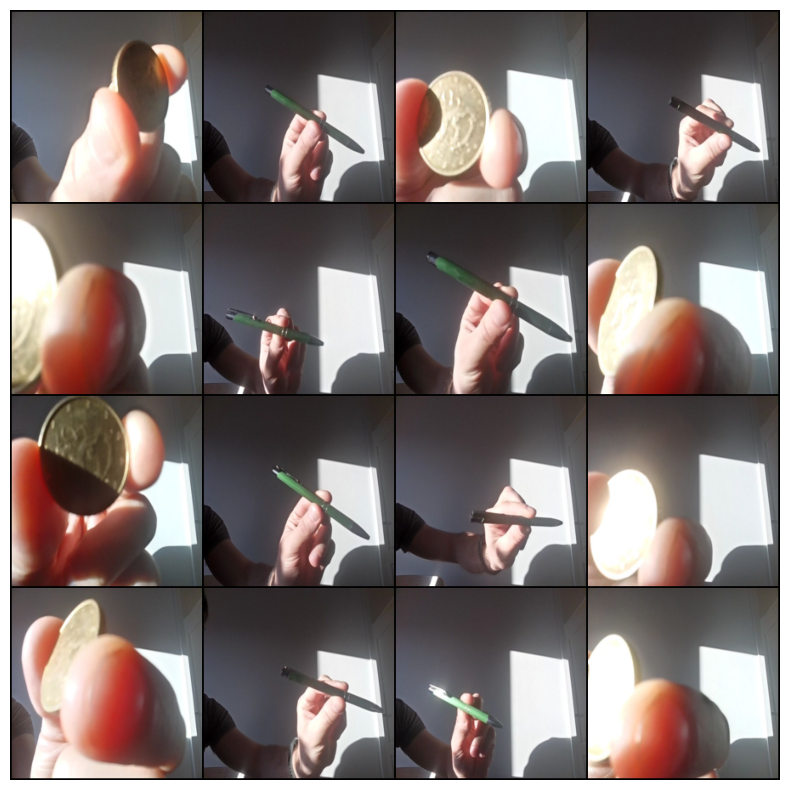

In [82]:
#### YOUR CODE STARTS HERE ####
test_dataset = CustomDataset(images_dir="data/ood", augment=False)
# Set shuffle=True to see a mix of classes in the visualization
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import torch

plt.rcParams['figure.figsize'] = (10.0, 10.0)

if len(test_dataset) > 0:
    images, labels = next(iter(test_loader))

    # unnormalize for display
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    images_disp = images.clone() * std + mean

    grid = make_grid(images_disp, nrow=4, padding=2)
    npimg = grid.permute(1, 2, 0).cpu().numpy()
    plt.imshow(np.clip(npimg, 0, 1))
    plt.axis('off')

    # print labels
    label_names = [test_dataset.class_names[int(l)] if hasattr(test_dataset, 'class_names') else int(l) for l in labels]
    print("Labels:", label_names)

    plt.show()
else:
    print("No images found in data/ood. Add images and re-run this cell.")
#### YOUR CODE ENDS HERE ####

<font color='red'> **(Homework exercise 5-b)** Evaluate all three models you have trained in the previous exercises on this new test set. Report the resulting accuracies for each (1 point).

In [83]:
#### YOUR CODE STARTS HERE ####
import os
from torch.utils.data import DataLoader

# pick OOD folder (fallback to data/test)
ood_dir = 'data/ood' if os.path.isdir('data/ood') and os.listdir('data/ood') else 'data/test'
test_dataset = CustomDataset(images_dir=ood_dir, augment=False)

if len(test_dataset) == 0:
    print("No test images in", ood_dir)
else:
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

    # candidate model variable names used in the notebook
    candidates = ['simple_model', 'model', 'your_crazy_model', 'crazy_model', 'your_model', 'YourCrazyCoolCNN_model']

    for name in candidates:
        if name in globals():
            m = globals()[name]
            try:
                m.to(device)
                preds = predict(m, test_loader)
                acc = float(np.mean(preds == test_dataset.labels))
                print(f"{name}: {acc:.4f}")
            except Exception as e:
                print(f"{name}: evaluation error ({e})")
#### YOUR CODE ENDS HERE ####

simple_model: 0.9833
model: 0.9000


<font color='red'> **(Homework exercise 5-c)** Discuss the results of the evaluation (1 point):
* <font color='red'> Describe shortly your OOD test set and explain how it is different from the training data.
* <font color='red'> Which model has performed best on the OOD test set? Why do you think this is the case?
</font>

<font color='black'> Your answer:</font>

## Bonus exercise 1 (2 points): Visualize model's activations
<font color='red'> Here we give you the unique opportunity to take a sneak peak at the internal activations of the model as it tries to classify the images from your dataset.

<font color='red'> We will use the method introduced in the paper [Visualizing and Understanding Convolutional Networks](https://arxiv.org/pdf/1311.2901.pdf).

<font color='red'>The general idea is to attach a so-called deconvnet to the already trained VGG-16 model. Deconvnnet consists of the same number of layers as the convnet, but arranged in the opposite order and performing opposite operations - transposed convolutions instead of usual convolutions and unpooling instead of pooling. Such architecture allows to map the feature maps from feature space back into pixel space. Of course, the mapping isn't perfect as some information is lost after max pooling operations, but it will still allow us to see the most prominent features identified by the model on input image.

<font color='red'> [Here](https://towardsdatascience.com/understand-transposed-convolutions-and-build-your-own-transposed-convolution-layer-from-scratch-4f5d97b2967) you can read more about transposed convolutions.

We prepared most of the code for you, you just need to *understand it* :), fill in some gaps and then visualize the reconstructed features (try it on images from both classes in your dataset). Don't forget to describe your results!</font>

In [ ]:
import torchvision.models as models
import json

In [ ]:
# get the names of ImageNet classes
!wget https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json

In [ ]:
class Vgg16Conv(nn.Module):
    """
    vgg16 convolution network architecture
    """

    def __init__(self, num_cls=1000):
        """
        Input
            number of classes, default is 1k as in the ImageNet.
        """
        super(Vgg16Conv, self).__init__()

        self.conv_layers = nn.Sequential(
            # conv1
            nn.Conv2d(3, 64, 3, padding='same'),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2, return_indices=True), # we need the indices of max values to later undo max pooling

            # conv
            nn.Conv2d(64, 128, 3, padding='same'),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2, return_indices=True),

            # conv3
            nn.Conv2d(128, 256, 3, padding='same'),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding='same'),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2, return_indices=True),

            # conv4
            nn.Conv2d(256, 512, 3, padding='same'),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding='same'),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2, return_indices=True),

            # conv5
            nn.Conv2d(512, 512, 3, padding='same'),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding='same'),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2, return_indices=True)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(4096, num_cls),
            nn.Softmax(dim=1)
        )

        # indices of conv layers in Sequential object, which behaves as a list
        self.conv_layer_indices = [0, 2, 5, 7, 10, 12, 14, 17, 19, 21, 24, 26, 28]
        # feature maps
        self.feature_maps = {}
        # indices of max values in pooling
        self.pool_locs = {}

        self.init_weights()

    def init_weights(self):
        """
        init weights from pretrained vgg16 model
        """
        vgg16_pretrained = models.vgg16(pretrained=True)

        # init Conv2d
        for idx, layer in enumerate(vgg16_pretrained.features):
            if isinstance(layer, nn.Conv2d):
                self.conv_layers[idx].weight.data = layer.weight.data
                self.conv_layers[idx].bias.data = layer.bias.data

        # init Linear
        for idx, layer in enumerate(vgg16_pretrained.classifier):
            if isinstance(layer, nn.Linear):
                self.classifier[idx + 1].weight.data = layer.weight.data
                self.classifier[idx + 1].bias.data = layer.bias.data

    def forward(self, x):
        self.feature_maps = {}
        self.pool_locs = {}

        for idx, layer in enumerate(self.conv_layers):
            if isinstance(layer, nn.MaxPool2d):
                x, location = layer(x)
                # save feature maps after every layer and locations of max values after max pooling
                self.feature_maps[idx] = x
                self.pool_locs[idx] = location
            else:
                x = layer(x)
                self.feature_maps[idx] = x

        output = self.classifier(x)
        return output

In [ ]:
class Vgg16Deconv(nn.Module):
    """
    vgg16 transposed convolution network architecture
    """
    def __init__(self):
        super(Vgg16Deconv, self).__init__()

        self.deconv_layers = nn.Sequential(
            # deconv1
            nn.MaxUnpool2d(2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(512, 512, 3, padding=1), # Pay attention to the number of channels in conv transpose layer - it starts from 512 as is in the last layer of VGG16 model
            nn.ReLU(),
            # pytorch supports 'same' and 'valid' keywords for padding in conv layers, but not in transposed conv layers :(
            nn.ConvTranspose2d(512, 512, 3, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(512, 512, 3, padding=1),

            # deconv2
            nn.MaxUnpool2d(2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(512, 512, 3, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(512, 512, 3, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(512, 256, 3, padding=1),

            # deconv3
            nn.MaxUnpool2d(2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 256, 3, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 256, 3, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 3, padding=1),

            # deconv4
            nn.MaxUnpool2d(2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 128, 3, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 3, padding=1),

            # deconv5
            nn.MaxUnpool2d(2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 3, padding=1)
        )

        # mapping of conv layers to corresponding transposed conv layers
        self.conv2deconv_indices = {
                0:30, 2:28, 5:25, 7:23,
                10:20, 12:18, 14:16, 17:13,
                19:11, 21:9, 24:6, 26:4, 28:2
                }

        self.unpool2pool_indices = {
                26:4, 21:9, 14:16, 7:23, 0:30
                }

        self.init_weight()

    def init_weight(self):
        vgg16_pretrained = models.vgg16(pretrained=True)
        for idx, layer in enumerate(vgg16_pretrained.features):
            if isinstance(layer, nn.Conv2d):
                self.deconv_layers[self.conv2deconv_indices[idx]].weight.data = layer.weight.data
                # Biases are optional, but you can experiment with adding or not adding them
                # self.features[self.conv2deconv_indices[idx]].bias.data = layer.bias.data[:self.features[self.conv2deconv_indices[idx]].bias.shape[0]]

    def forward(self, x, layer, pool_locs):
        if layer in self.conv2deconv_indices:
            start_idx = self.conv2deconv_indices[layer]
        else:
            raise ValueError('layer is not a conv feature map')

        # start deconv from deconv layer which corresponds to conv layer
        # which produced the feature maps and move upwards
        #### YOUR CODE STARTS HERE ####
        ...
        #### YOUR CODE ENDS HERE ####

        return x

In [ ]:
def visualise_layer(layer, conv_model, deconv_model, max_activations_only=True):
    """
    visualing the layer deconv result
    max_activations_only: whether to set all non-max activations to 0
    """
    num_feat = conv_model.feature_maps[layer].shape[1]

    new_feat_map = conv_model.feature_maps[layer].clone().detach() # 1 x num_filters x h x w

    if max_activations_only:

        #### YOUR CODE STARTS HERE ####
        # find index of feature map with max activation value
        ...
        # find max activation value
        ...

        # set all other feature maps to 0
        ...
        ...

        # set all activations < max activation in max feature map to 0
        ...

        #### YOUR CODE ENDS HERE ####


    deconv_output = deconv_model(new_feat_map, layer, conv_model.pool_locs)

    new_img = deconv_output.detach().cpu().numpy()[0].transpose(1, 2, 0)  # h x w x c

    # scale output to be between 0 and 1
    new_img = (new_img - new_img.min()) / (new_img.max() - new_img.min())
    new_img *= 255
    new_img = new_img.astype(np.uint8)

    return new_img

In [ ]:
# Just to make feature maps a bit brighter :)
def make_prettier(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)

    # set vibrance
    vibrance = 3

    # create 256 element non-linear LUT for sigmoidal function
    # see https://en.wikipedia.org/wiki/Sigmoid_function
    xval = np.arange(0, 256)
    lut = (255*np.tanh(vibrance*xval/255)/np.tanh(1)+0.5).astype(np.uint8)

    # apply lut to saturation channel
    new_s = cv2.LUT(s,lut)

    # combine new_s with original h and v channels
    new_hsv = cv2.merge([h,new_s,v])

    # convert back to RGB
    result =  cv2.cvtColor(new_hsv,  cv2.COLOR_HSV2RGB)
    return result

In [ ]:
def load_images(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
        ])

    t_img = transform(img)
    t_img.unsqueeze_(0)
    t_img = t_img.to(device)
    return img, t_img

In [ ]:
# Get the actual ImageNet class label for prediction
def decode_predictions(preds, top=3):
    with open('imagenet_class_index.json') as f:
            class_index_dict = json.load(f)

    results = []
    for pred in preds:
        top_value, top_indices = torch.topk(pred, top)
        result = [[class_index_dict[str(i.item())][1], j.item()] for (i, j) in zip(top_indices, top_value)]
        results.append(result)

    return results

In [ ]:
vgg16_conv = Vgg16Conv()
vgg16_conv.eval()
vgg16_conv.to(device)

vgg16_deconv = Vgg16Deconv()
vgg16_deconv.eval()
vgg16_deconv.to(device)

In [ ]:
img_path = ''
img, in_img = load_images(img_path)

with torch.no_grad():
  out = vgg16_conv(in_img)

print('Predicted:', decode_predictions(out.detach().cpu(), top=3)[0])

In [ ]:
plt.figure(num=None, figsize=(16, 12), dpi=80)
plt.subplot(3, 4, 1)
plt.title('original picture')
plt.imshow(img)

for idx, layer in enumerate(vgg16_conv.conv_layer_indices[1:-1]):
    plt.subplot(3, 4, idx+2)
    out_img = visualise_layer(layer, vgg16_conv, vgg16_deconv, True)
    plt.title(f'conv layer {idx + 2}')
    plt.imshow(make_prettier(out_img))

plt.show()

 Your interpretation of results goes in here:

# Comments (optional feedback to the course instructors)
Here, please, leave your comments regarding the homework, possibly answering the following questions:
* how much time did you send on this homework?
* was it too hard/easy for you?
* what would you suggest to add or remove?
* anything else you would like to tell us

Your comments:

# <font color='red'>  End of the homework. Please don't delete this cell.</font>